In [21]:

import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV

In [22]:
url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
df_bank = pd.read_csv(url, sep=";")
df_bank.shape, df_bank.head().T


((41188, 21),
                           0            1            2            3  \
 age                      56           57           37           40   
 job               housemaid     services     services       admin.   
 marital             married      married      married      married   
 education          basic.4y  high.school  high.school     basic.6y   
 default                  no      unknown           no           no   
 housing                  no           no          yes           no   
 loan                     no           no           no           no   
 contact           telephone    telephone    telephone    telephone   
 month                   may          may          may          may   
 day_of_week             mon          mon          mon          mon   
 duration                261          149          226          151   
 campaign                  1            1            1            1   
 pdays                   999          999          999         

##### EDA 

Eliminamos duplicados

In [23]:
df_bank = df_bank.drop_duplicates().reset_index(drop=True)
df_bank.shape

(41176, 21)

In [24]:
df_bank.isna().sum().head()

age          0
job          0
marital      0
education    0
default      0
dtype: int64

Comprobamos el balance de nuestra variable objetivo

In [25]:
(df_bank["y"].value_counts(normalize=True)*100).round(2)

y
no     88.73
yes    11.27
Name: proportion, dtype: float64

La variable objetivo esta muy desbalanceada, 11.27% de clientes que han contratado un deposito a largo plazo, esto nos dará una idea de que métricas valorar, ya que accuracy puede ser engañosa.


#### Gráficos
En el siguiente paso vamos a intentar entender cuanta variedad tiene cada categórica (cardinalidad)

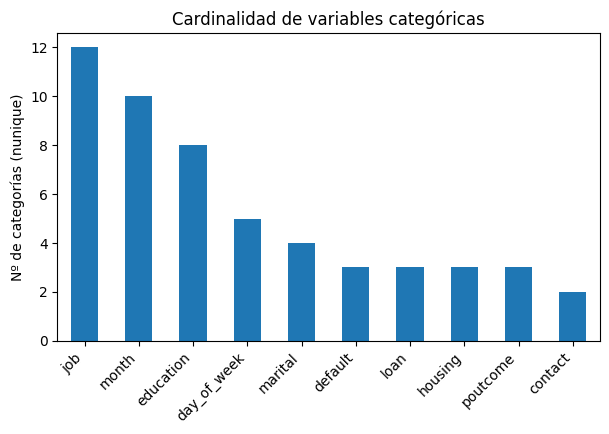

In [26]:
df_bank.dtypes
#separamos categoricas de numericas y quitamos "y" para que la cardinalidad sea solo de las predictoras
cat_var = df_bank.select_dtypes(exclude="number").columns.tolist()
cat_var = [c for c in cat_var if c != "y"]
num_var = df_bank.select_dtypes(include="number").columns.tolist()

#cardinalidad de las variables categóricas
cat_card = df_bank[cat_var].nunique().sort_values(ascending=False)

plt.figure(figsize=(7,4))
cat_card.plot(kind="bar")
plt.ylabel("Nº de categorías (nunique)")
plt.title("Cardinalidad de variables categóricas")
plt.xticks(rotation=45, ha="right")
plt.show()


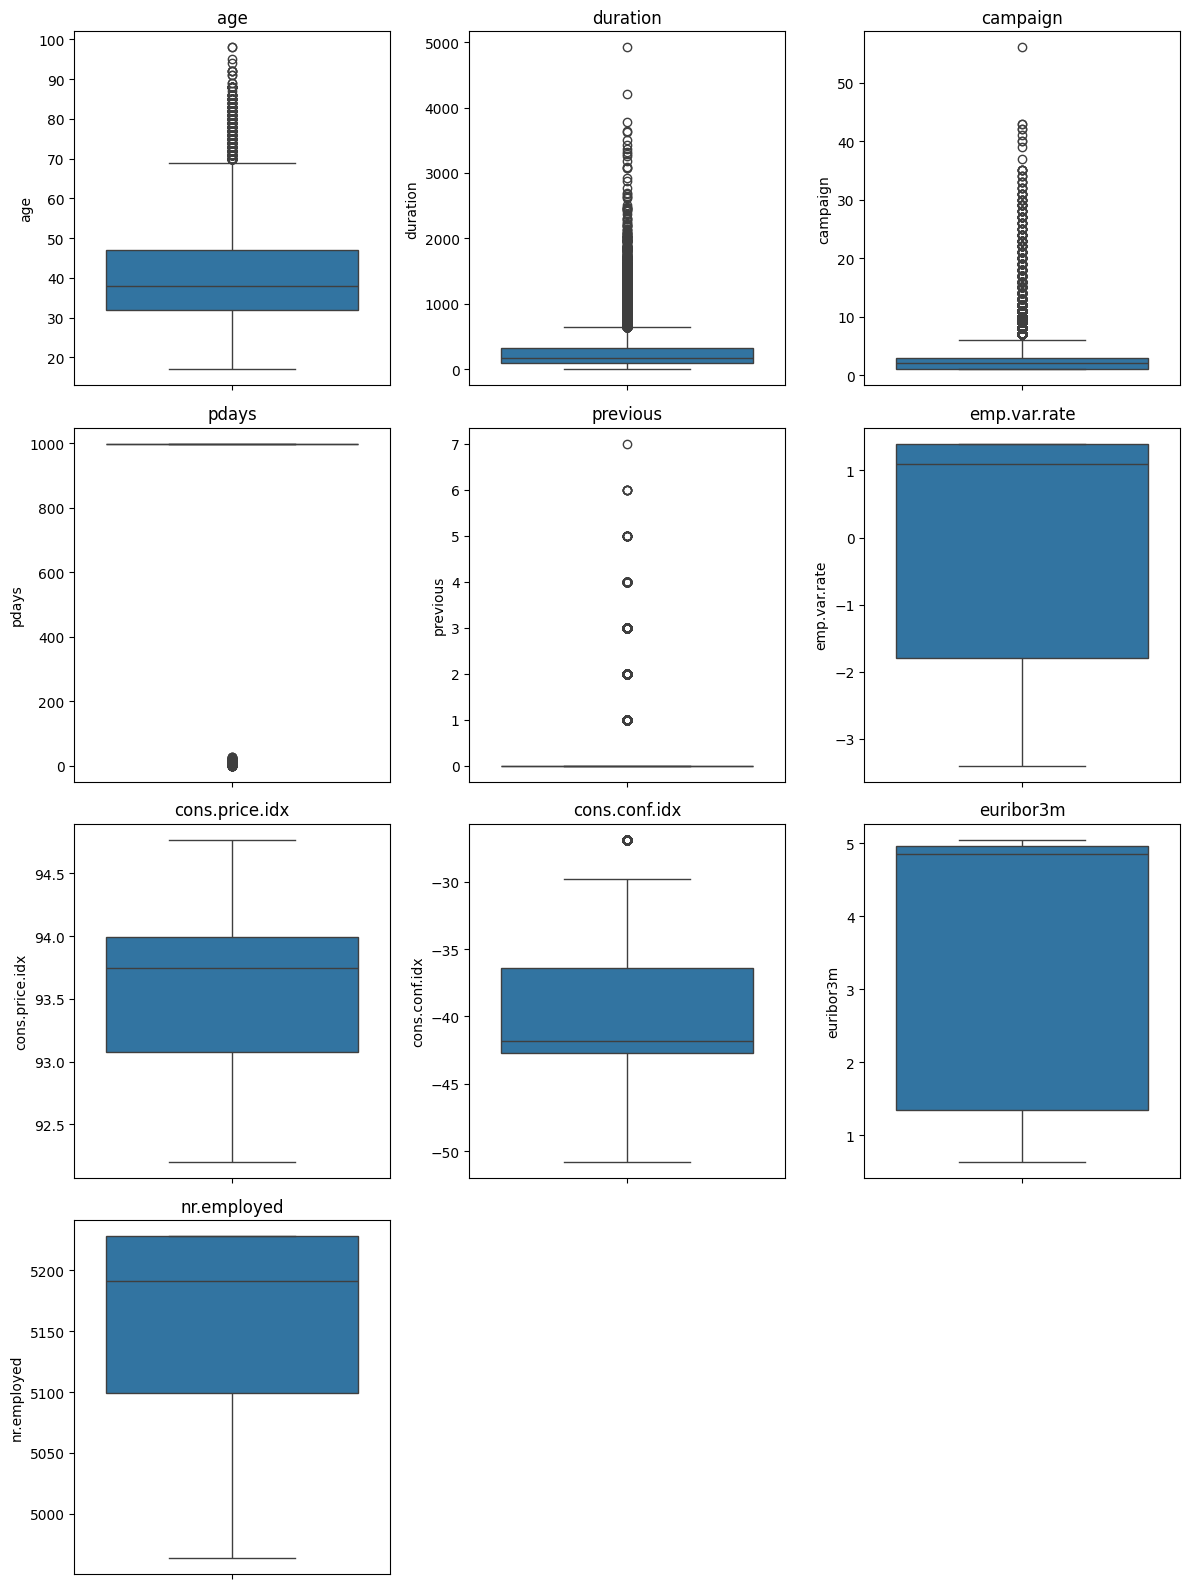

In [27]:
num_cols = df_bank.select_dtypes(include="number").columns.tolist()

n = len(num_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df_bank[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

# apagar ejes sobrantes
for _ in range(i+1, len(axes)):
    axes[_].axis("off")

plt.tight_layout()
plt.show()


Con estos resultados podemos entender que usaremos `StandardScaler()` para homogeneizar las numericas y `OneHotEncoder()` en categoricas para convertirlas en binarias. En este boxplot podemos ver que la variable `Duration` tiene una distribución muy asimétrica y con numerosos valores extremos, lo que podría hacer que el modelo dependa excesivamente de esta variable. Además, eliminaremos esta variable porque representa un dato conocido únicamente despues de realizar la llamada, como el objetivo es priorizar a que clientes contactar antes de llamar.

In [28]:
df_bank = df_bank.drop(columns=["duration"])
df_bank.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


 Vamos a ver ahora una correlación de las variables númericas con la variable objetivo.

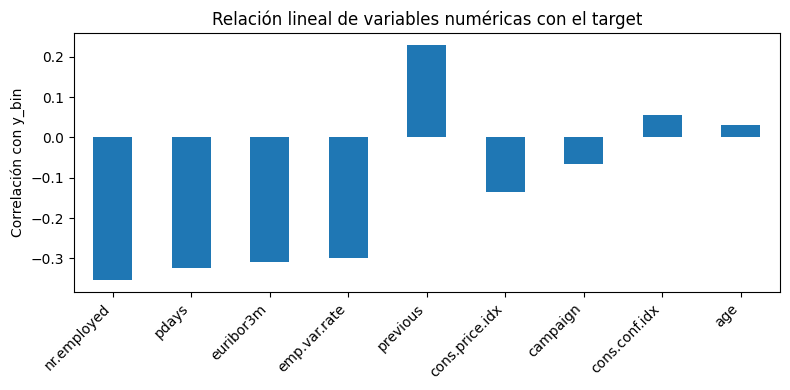

In [29]:
df_corr = df_bank.copy()
df_corr["y_bin"] = (df_corr["y"] == "yes").astype(int)

corr_y = df_corr.select_dtypes(include="number").corr()["y_bin"].drop("y_bin")
corr_y = corr_y.sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(8,4))
corr_y.plot(kind="bar")
plt.ylabel("Correlación con y_bin")
plt.title("Relación lineal de variables numéricas con el target")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Calculamos la correlación de variables numéricas con el target binario (y_bin para poder calcular correlaciones con variables numéricas, ya que la correlación requiere valores numéricos.) como una aproximación rápida de relación lineal. Observamos que previous es la variable con mayor asociación positiva, mientras que los indicadores macroeconómicos (euribor3m, emp.var.rate, nr.employed) y pdays se relacionan negativamente con la suscripción. Estas relaciones son orientativas (solo captan dependencia lineal), pero ayudan a identificar variables potencialmente relevantes para el modelo.
Por otra parte podemos ver que en pdays no sale el valor "999" que significa que el cliente no ha sido contactado previamente lo cual nos indica que debemos interpretarlo concautela.

#### División de datos en entrenamiento y test

En este paso separaremos las variables predictoras en `X` y en `y` la variable objetivo. Convertiremos `y` a binaria (1 = “yes”, 0 = “no”), haremos train/test split para evaluar el modelo en datos no vistos, donde usaremos `stratify=y` ya que la variable objetivo está desbalanceada y asi mantenemos en el conjunto de test una proporción similar.

In [30]:
X = df_bank.drop(columns=["y"])           # X = variables predictoras (todas menos el target)
y = (df_bank["y"] == "yes").astype(int)   # y = target en formato numérico: yes→1, no→0

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        
    random_state=42,     
    stratify=y #mantiene el mismo % de clases en train y test (muy importante con desbalance)
)

X_train.shape, X_test.shape

((32940, 19), (8236, 19))

Comprobamos que se mantiene el desbalance proporcionalmente

In [31]:
y_train.value_counts(normalize=True)*100, y_test.value_counts(normalize=True)*100

(y
 0    88.734062
 1    11.265938
 Name: proportion, dtype: float64,
 y
 0    88.732394
 1    11.267606
 Name: proportion, dtype: float64)

#### Preprocesado

##### One Hot encoding

In [32]:
# OneHot encoding, alinear para que train y test tengan las mismas collumnas train/test)
X_train_d = pd.get_dummies(X_train, drop_first=True)
X_test_d  = pd.get_dummies(X_test, drop_first=True)

X_test_d = X_test_d.reindex(columns=X_train_d.columns, fill_value=0)

X_train_d.shape, X_test_d.shape

((32940, 52), (8236, 52))

##### Escalado

In [33]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_d)
X_test_s  = scaler.transform(X_test_d)

#### Modelo de Regresión Logística

##### Entrenar modelo básico

In [34]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_s, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


#### Evaluación

In [35]:
y_pred = lr.predict(X_test_s)
y_proba = lr.predict_proba(X_test_s)[:, 1]#solo nos quedamos con la probabilidad de la clase 1 para ROC_AUC

#### Métricas

Precisión, recall, f1_score, suport

In [36]:
report = classification_report(y_test, y_pred, output_dict=True)
df_cr = pd.DataFrame(report).T
df_cr

,precision,recall,f1-score,support
0,0.907533,0.985769,0.945035,7308.000000
1,0.651007,0.209052,0.316476,928.000000
accuracy,0.898252,0.898252,0.898252,0.898252
macro avg,0.779270,0.597410,0.630756,8236.000000
weighted avg,0.878629,0.898252,0.874211,8236.000000


Matriz de confusión

In [37]:
mc = confusion_matrix(y_test, y_pred)
df_mc = pd.DataFrame(mc,
                     index=["Real: 0", "Real: 1"],
                     columns=["Pred: 0", "Pred: 1"])
df_mc

,Pred: 0,Pred: 1
Real: 0,7204,104
Real: 1,734,194


ROC_AUC

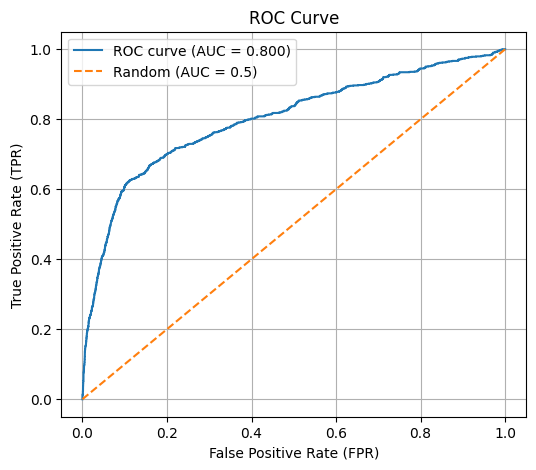

In [38]:
y_proba = lr.predict_proba(X_test_s)[:, 1]

#curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Con estos resultados el modelo es util para identificar los clientes existentes con mayor probabilidad de contratar un depósito a largo plazo usando `predict_proba`. El roc-auc = 80 indica que el modelo distingue razonablemente entre clientes con más y menos probabilidades de contratar, por lo que sirve como sistema de *scoring* para clasificar clientes de mayor a menor probabilidad. 

La matriz de confusión muestra que el modelo acierta muy bien los clientes que no contratarán (7204 verdaderos negativos y solo 104 falsos positivos), y cuando un "sí" es fiable (precision clase 1 = 0.65), aunque detecta pocos "si" fiables (recall clase 1 =0,21), lo que significa que deja fuera muchos posibles clientes que contratarían.
Este modelo serviría  para seleccionar los mejores clientes conprobabilidad de contratar. 

#### Optimización

##### GridSearchCV

In [ ]:
param_grid = {"C": [0.01, 0.1, 10],
              "class_weight": [None, "balanced"]}

#volvemos a entrenar el modelo con parámetros nuevos
base_lr = LogisticRegression(max_iter=2000,
                             penalty="l2",
                             solver="lbfgs",
                             random_state=42)
                       

grid = GridSearchCV(estimator=base_lr,
                    param_grid=param_grid,
                    scoring="f1",
                    cv=5,
                    n_jobs=-1)

grid.fit(X_train_s, y_train)

grid.best_params_, grid.best_score_

({'C': 10, 'class_weight': 'balanced'}, np.float64(0.45188787928460733))

Evaluar el mejor modelo obtenido en test

In [43]:
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test_s)
y_proba_best = best_lr.predict_proba(X_test_s)[:,1]

##### Métricas optimizadas con GridSearchCV 

In [ ]:
best_report = classification_report(y_test, y_pred_best, output_dict=True)

df_bcr = pd.DataFrame(best_report).T
df_bcr


,precision,recall,f1-score,support
0,0.949932,0.854132,0.899488,7308.000000
1,0.359760,0.645474,0.462013,928.000000
accuracy,0.830622,0.830622,0.830622,0.830622
macro avg,0.654846,0.749803,0.680751,8236.000000
weighted avg,0.883433,0.830622,0.850195,8236.000000


Matriz de confusión

In [44]:
bmc = confusion_matrix(y_test, y_pred_best)
df_bmc = pd.DataFrame(bmc,
                     index=["Real: 0", "Real: 1"],
                     columns=["Pred: 0", "Pred: 1"])
df_bmc

,Pred: 0,Pred: 1
Real: 0,6242,1066
Real: 1,329,599


##### ROC-AUC

In [45]:
roc_auc_score(y_test, y_proba)

0.8004314915869241

#### Conclusión

El objetivo de este proyecto este proyecto es identificar a los clientes que tienen una mayor probabilidad de contratar un depósito. 

En el conjunto de test, para la clase "yes" (clientes que contratan), en recall  tenemos 0.645, es decir un 65% de los clientes que realmente contratarían. La precisión = 0,36 lo que indica que solo el 36% de los que el modelo marca como probables terminan contratando el depósito.

En la matriz de confusión podemos ver como el modelo acierta muchos "no", 6242 verdaderos negativos. Por otra, parte detecta  menos "yes", 599 verdaderos positivos y genera muchas llamadas innecesarias, 1066 falsos positivos.

Ante el modfelo base, el modelo optimizado (C=10, class_weight="balanced") mejora la identificación de clientes “yes”, aumentando el recall y el F1 de la clase positiva, lo que lo hace mas útil para priorizar llamadas. A cambio, aparecen mas falsos positivos (baja la precisión/accuracy). El ROC-AUC se mantiene igual, por lo que la mejora proviene principalmente del ajuste al desbalance, no de una mayor capacidad de separación de clientes que contratarían o no el depósito.
